# Experiment 7: Hierarchical Clustering

**Description:** Implement an agglomerative hierarchical clustering method on the Bitcoin case-study
dataset, generate dendrograms to visualise how the clusters form, and analyse the hierarchical
relationships between the data instances.

**Deliverables:** Python notebook, dendrogram, cluster interpretation.

**Two analyses**
1. **Monthly market profiles** (188 months, 4 features) — the natural unit for a readable dendrogram; each
   leaf is one month of Bitcoin trading.
2. **Individual trading days** (sample of 500, same 2 features as Experiment 6) — so the hierarchical
   result can be compared directly against the K-Means partition.

The agglomerative algorithm itself is written from first principles (proximity matrix + Lance-Williams
update). SciPy is used only to draw dendrograms and to verify the from-scratch merge order.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist, squareform

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option("display.width", 150); pd.set_option("display.max_columns", 30)

import os, warnings
warnings.filterwarnings('ignore')
OUT = "exp7_outputs"; os.makedirs(OUT, exist_ok=True)

## 1. Data Preparation

### 1.1 Monthly market profiles
Each month is described by four scale-free features, then standardised so that no feature dominates the
distance.

In [2]:
df = pd.read_csv("btc_preprocessed_v1.csv", parse_dates=['date'])
df['month'] = df['date'].dt.to_period('M')

monthly_all = df.groupby('month').agg(
    mean_return   = ('daily_pct_change', 'mean'),
    volatility    = ('daily_pct_change', 'std'),
    mean_range    = ('range_pct', 'mean'),
    pct_up_days   = ('daily_pct_change', lambda s: (s > 0).mean() * 100),
    days          = ('close', 'size'),
    interpolated  = ('is_interpolated', 'sum'),
    close_end     = ('close', 'last')).reset_index()
monthly_all['interp_share'] = monthly_all['interpolated'] / monthly_all['days'] * 100
monthly_all['label'] = monthly_all['month'].astype(str)

FEATURES = ['mean_return', 'volatility', 'mean_range', 'pct_up_days']
print(f"Months available: {len(monthly_all)}")

# ---- exclusion 1: part months (fewer than 20 trading days) ----
part = monthly_all[monthly_all['days'] < 20]
# ---- exclusion 2: months mostly reconstructed by interpolation ----
synthetic = monthly_all[(monthly_all['days'] >= 20) & (monthly_all['interp_share'] > 25)]
# ---- exclusion 3: statistical outlier months (|z| > 3 on any feature) ----
base = monthly_all[(monthly_all['days'] >= 20) & (monthly_all['interp_share'] <= 25)]
zz = (base[FEATURES] - base[FEATURES].mean()) / base[FEATURES].std()
outlier = base[(zz.abs() > 3).any(axis=1)]

monthly = base.drop(index=outlier.index).reset_index(drop=True)

print(f"  excluded, part month (<20 days)        : {len(part)}  {part['label'].tolist()}")
print(f"  excluded, >25% interpolated days       : {len(synthetic)}  "
      f"{[f'{r.label} ({r.interp_share:.0f}%)' for r in synthetic.itertuples()]}")
print(f"  excluded, statistical outlier (|z|>3)  : {len(outlier)}  {outlier['label'].tolist()}")
print(f"  months clustered                       : {len(monthly)}  "
      f"({monthly['label'].iloc[0]} to {monthly['label'].iloc[-1]})")

Xm_raw = monthly[FEATURES].to_numpy(float)
Xm = (Xm_raw - Xm_raw.mean(axis=0)) / Xm_raw.std(axis=0)             # z-score, written out
print()
print(monthly[FEATURES].describe().round(3).to_string())
monthly.head()

Months available: 182
  excluded, part month (<20 days)        : 0  []
  excluded, >25% interpolated days       : 2  ['2024-12 (71%)', '2025-01 (84%)']
  excluded, statistical outlier (|z|>3)  : 4  ['2011-04', '2013-04', '2013-11', '2014-02']
  months clustered                       : 176  (2011-02 to 2026-03)

       mean_return  volatility  mean_range  pct_up_days
count      176.000     176.000     176.000      176.000
mean         0.254       3.635       5.489       52.112
std          0.806       2.252       3.089        9.980
min         -1.527       1.046       1.802       25.806
25%         -0.245       2.278       3.533       45.161
50%          0.140       3.122       4.550       51.613
75%          0.693       4.249       6.550       58.065
max          3.718      15.245      19.735       77.419


,month,mean_return,volatility,mean_range,pct_up_days,days,interpolated,close_end,interp_share,label
0,2011-02,2.266845,10.123451,13.677128,50.000000,28,0,0.8600,0.0,2011-02
1,2011-03,-0.233117,3.612530,6.745937,35.483871,31,0,0.7846,0.0,2011-03
2,2011-05,3.718470,13.126199,17.013891,54.838710,31,0,8.7400,0.0,2011-05
3,2011-06,3.191290,15.245472,19.735317,46.666667,30,0,16.1000,0.0,2011-06
4,2011-07,-0.527714,3.967559,7.255242,41.935484,31,0,13.3500,0.0,2011-07


### 1.2 Why those months are excluded

Hierarchical clustering has no notion of an outlier: every point must end up somewhere in the tree, so a
single extreme month becomes its own branch and consumes one of the top-level clusters. Three groups are
therefore removed before clustering, and reported rather than hidden:

- **Part months** with fewer than 20 trading days, whose statistics are not comparable.
- **Months rebuilt by interpolation** — December 2024 and January 2025 contain the 49-day recording gap
  filled in Experiment 4. Their volatility is artificially low because a straight line has no variance.
- **Statistical outlier months** (|z| > 3 on any feature) — February 2014, the Mt. Gox collapse.

## 2. Agglomerative Clustering From Scratch

The algorithm (AGNES):

1. Start with **n singleton clusters** and compute the full proximity matrix.
2. Find the **closest pair** of clusters and merge them.
3. **Update the distances** from the new cluster to all others using the linkage rule.
4. Repeat until one cluster remains, recording every merge — that record is the dendrogram.

The three classical linkages, all special cases of the **Lance-Williams** update formula
$d(k, i \cup j) = \alpha_i d(k,i) + \alpha_j d(k,j) + \beta d(i,j) + \gamma |d(k,i) - d(k,j)|$:

| Linkage | Distance between clusters | Lance-Williams coefficients |
|---|---|---|
| **Single** | nearest pair of points (minimum) | αi = αj = ½, β = 0, γ = −½ |
| **Complete** | farthest pair of points (maximum) | αi = αj = ½, β = 0, γ = +½ |
| **Average (UPGMA)** | mean of all cross-cluster distances | αi = ni/(ni+nj), αj = nj/(ni+nj), β = γ = 0 |
| **Ward** | merge that increases within-cluster variance least | αi = (ni+nk)/(ni+nj+nk), αj = (nj+nk)/(ni+nj+nk), β = −nk/(ni+nj+nk), γ = 0 (on squared distances) |

In [3]:
def euclidean_matrix(X):
    """Full n x n Euclidean proximity matrix, computed directly from the definition."""
    diff = X[:, None, :] - X[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))

def agglomerative(X, method='average'):
    """AGNES with the Lance-Williams update. Returns a SciPy-compatible linkage matrix
    Z with rows [cluster_a, cluster_b, distance, size]."""
    n = len(X)
    D = euclidean_matrix(X).astype(float)
    np.fill_diagonal(D, np.inf)

    active = list(range(n))          # current cluster ids (0..n-1 are the singletons)
    size = {i: 1 for i in range(n)}
    idx = {i: i for i in range(n)}   # cluster id -> row/col in D
    Z = []
    next_id = n

    for step in range(n - 1):
        # --- 2. closest pair among the active clusters ---
        best = (np.inf, None, None)
        for a_pos in range(len(active)):
            for b_pos in range(a_pos + 1, len(active)):
                a, b = active[a_pos], active[b_pos]
                d = D[idx[a], idx[b]]
                if d < best[0]:
                    best = (d, a, b)
        dist, a, b = best
        na, nb = size[a], size[b]

        # --- 3. Lance-Williams update of the distances to the merged cluster ---
        ia, ib = idx[a], idx[b]
        for k in active:
            if k in (a, b):
                continue
            ik = idx[k]
            dka, dkb = D[ik, ia], D[ik, ib]
            if method == 'single':
                new = 0.5 * dka + 0.5 * dkb - 0.5 * abs(dka - dkb)      # = min
            elif method == 'complete':
                new = 0.5 * dka + 0.5 * dkb + 0.5 * abs(dka - dkb)      # = max
            elif method == 'average':
                new = (na * dka + nb * dkb) / (na + nb)
            elif method == 'ward':                                   # Lance-Williams on squared distances
                nk = size[k]
                new = np.sqrt(((na + nk) * dka ** 2 + (nb + nk) * dkb ** 2 - nk * dist ** 2)
                              / (na + nb + nk))
            else:
                raise ValueError(method)
            D[ik, ia] = D[ia, ik] = new          # reuse row ia for the merged cluster

        # --- record the merge ---
        Z.append([a, b, dist, na + nb])
        active.remove(a); active.remove(b)
        idx[next_id] = ia                        # merged cluster lives in row ia
        size[next_id] = na + nb
        active.append(next_id)
        next_id += 1

    return np.array(Z, dtype=float)

Z_scratch = agglomerative(Xm, method='average')
print("Linkage matrix built from scratch — first 8 merges")
print(pd.DataFrame(Z_scratch[:8], columns=['cluster_a', 'cluster_b', 'distance', 'size']).round(4).to_string(index=False))
print(f"\nTotal merges: {len(Z_scratch)} (= n - 1 = {len(Xm)} - 1)")
print(f"Final merge distance (root of the dendrogram): {Z_scratch[-1, 2]:.4f}")

Linkage matrix built from scratch — first 8 merges
 cluster_a  cluster_b  distance  size
      47.0       88.0    0.0923   2.0
     138.0      145.0    0.1225   2.0
     165.0      167.0    0.1260   2.0
      63.0      147.0    0.1377   2.0
     144.0      164.0    0.1562   2.0
      46.0       87.0    0.1574   2.0
      12.0      163.0    0.1684   2.0
      91.0      104.0    0.1766   2.0

Total merges: 175 (= n - 1 = 176 - 1)
Final merge distance (root of the dendrogram): 6.5258


In [4]:
# Verification: the same data through SciPy's implementation
Z_scipy = linkage(Xm, method='average')
same_pairs = np.array_equal(np.sort(Z_scratch[:, :2], axis=1), np.sort(Z_scipy[:, :2], axis=1))
max_dist_diff = np.abs(Z_scratch[:, 2] - Z_scipy[:, 2]).max()
print("VERIFICATION against scipy.cluster.hierarchy.linkage")
print(f"  identical merge sequence : {same_pairs}")
print(f"  max difference in merge heights : {max_dist_diff:.2e}")
print(f"  identical cluster sizes  : {np.array_equal(Z_scratch[:, 3], Z_scipy[:, 3])}")

VERIFICATION against scipy.cluster.hierarchy.linkage
  identical merge sequence : True
  max difference in merge heights : 1.78e-15
  identical cluster sizes  : True


## 3. Comparing the Three Linkage Methods

The **cophenetic correlation coefficient** measures how faithfully the dendrogram preserves the original
pairwise distances — the closer to 1, the less the tree distorts the data.

In [5]:
rows = []
Zs = {}
for method in ['single', 'complete', 'average', 'ward']:
    Z = agglomerative(Xm, method=method)
    Zs[method] = Z
    Zsp = linkage(Xm, method=method)                      # for cophenet (identical merges)
    coph, _ = cophenet(Zsp, pdist(Xm))
    heights = Z[:, 2]
    sizes4 = np.bincount(fcluster(Zsp, 4, criterion='maxclust'))[1:]
    rows.append({'linkage': method,
                 'cophenetic corr': round(coph, 4),
                 'root height': round(heights[-1], 3),
                 'cluster sizes at k=4': str(sorted(sizes4.tolist(), reverse=True)),
                 'largest cluster %': round(sizes4.max() / len(Xm) * 100, 1)})
print("LINKAGE COMPARISON")
print(pd.DataFrame(rows).to_string(index=False))
print()
print("Single linkage suffers from chaining - long straggly clusters formed by nearest-neighbour hops.")
print("Average linkage preserves the pairwise distances best (highest cophenetic correlation), but on")
print("this data it puts 95% of the months into one cluster, so the cut says very little.")
print("Ward linkage minimises the increase in within-cluster variance at every merge and gives the most")
print("balanced, most interpretable partition, so it is used for the analysis below.")

LINKAGE COMPARISON
 linkage  cophenetic corr  root height cluster sizes at k=4  largest cluster %
  single           0.8274        2.542       [172, 2, 1, 1]               97.7
complete           0.7387        9.597      [160, 10, 4, 2]               90.9
 average           0.8483        6.526       [168, 4, 3, 1]               95.5
    ward           0.6063       20.691      [94, 57, 23, 2]               53.4

Single linkage suffers from chaining - long straggly clusters formed by nearest-neighbour hops.
Average linkage preserves the pairwise distances best (highest cophenetic correlation), but on
this data it puts 95% of the months into one cluster, so the cut says very little.
Ward linkage minimises the increase in within-cluster variance at every merge and gives the most
balanced, most interpretable partition, so it is used for the analysis below.


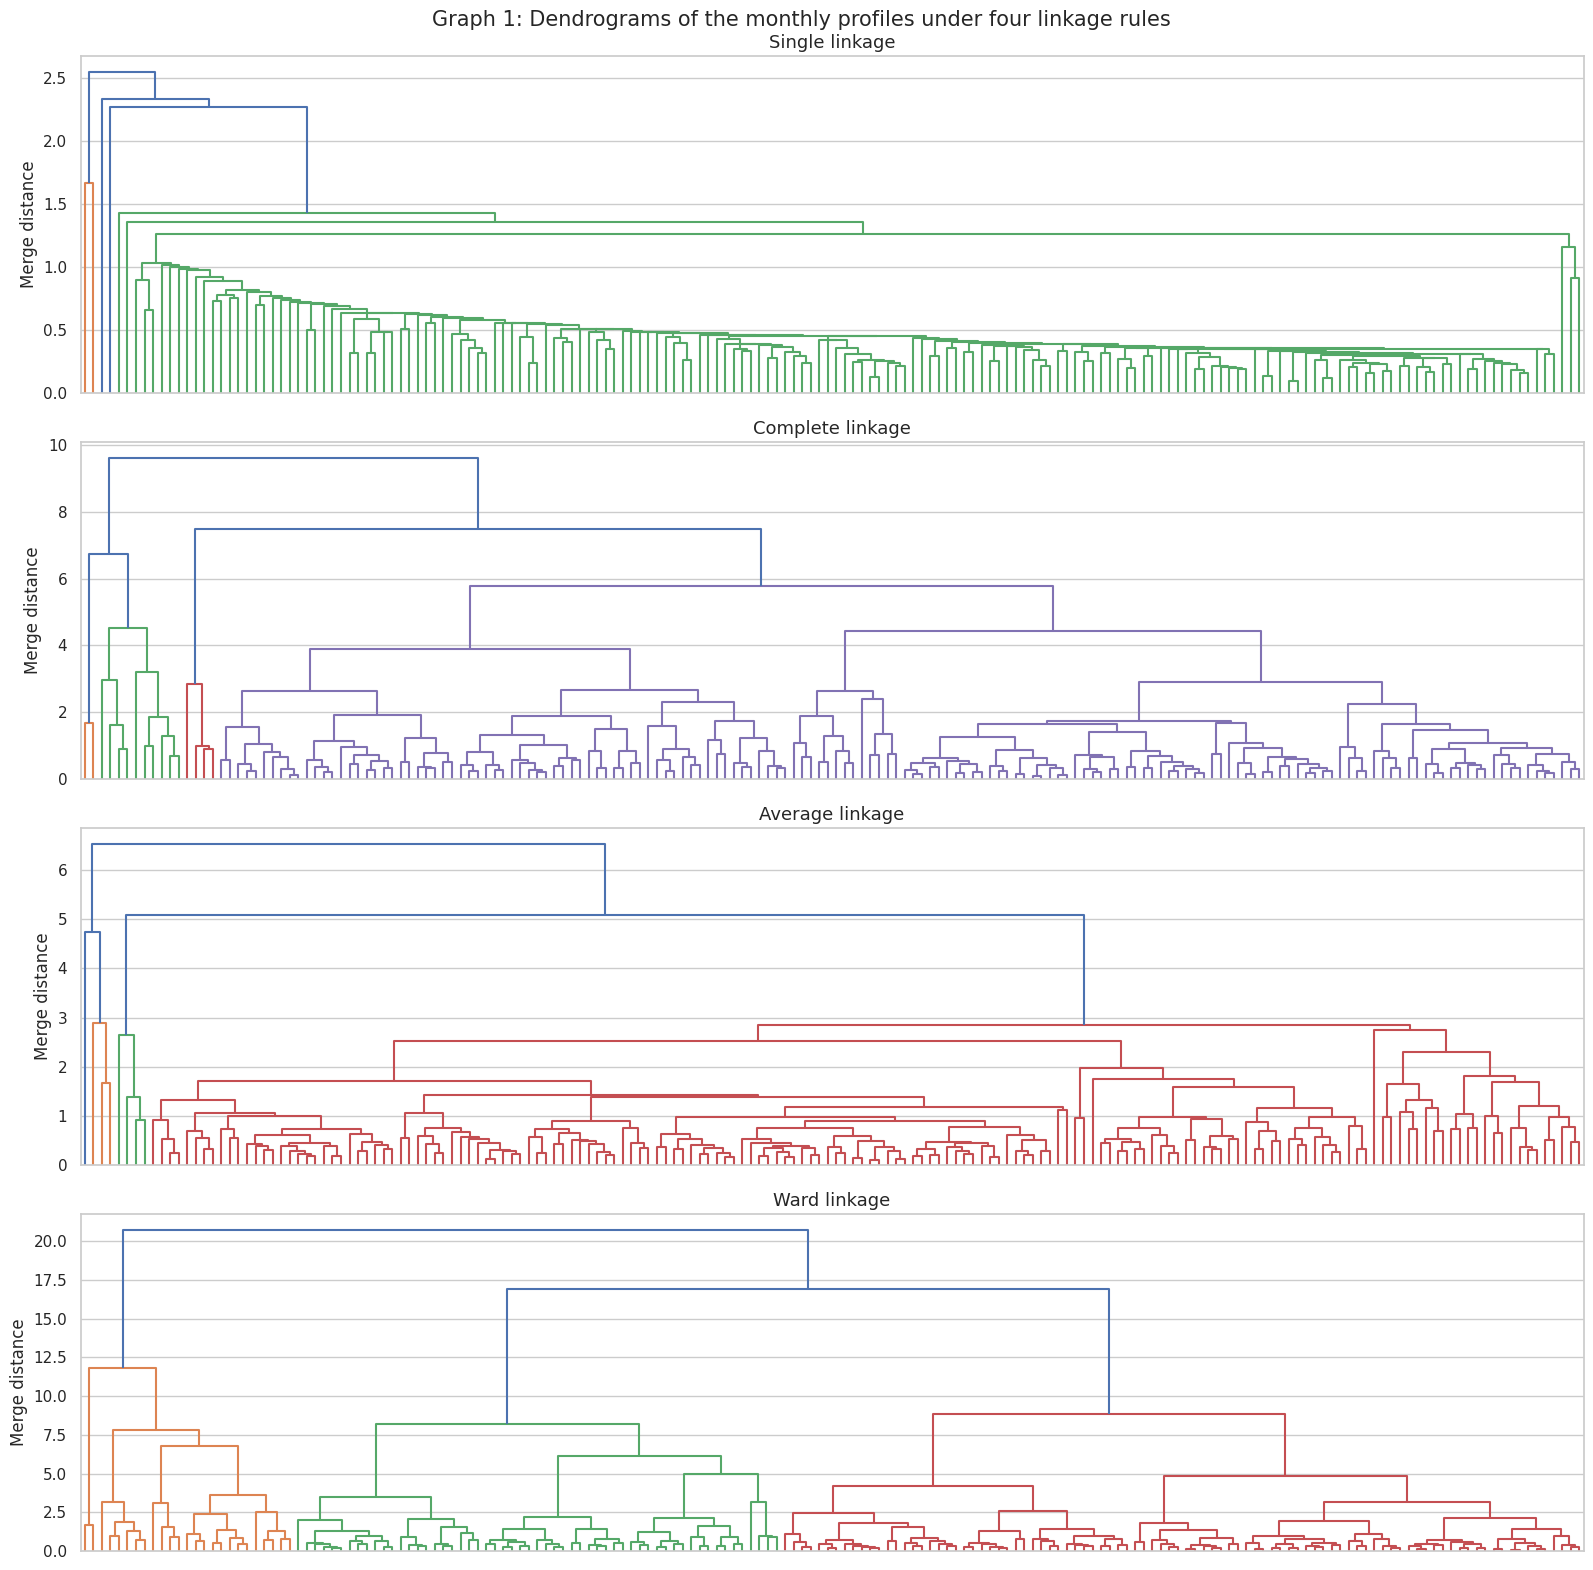

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(16, 16))
for ax, method in zip(axes, ['single', 'complete', 'average', 'ward']):
    dendrogram(linkage(Xm, method=method), ax=ax, no_labels=True, color_threshold=None)
    ax.set_title(f'{method.capitalize()} linkage', fontsize=13)
    ax.set_ylabel('Merge distance')
fig.suptitle('Graph 1: Dendrograms of the monthly profiles under four linkage rules', fontsize=15)
plt.tight_layout(); plt.savefig(f"{OUT}/exp7_g1_linkage_comparison.png", dpi=150); plt.show()

## 4. The Chosen Dendrogram — Ward Linkage

Ward linkage is used for the analysis: it merges the pair of clusters whose union increases the total
within-cluster variance least, which on this data is the only rule of the four that produces a balanced,
interpretable partition. The cut level is chosen where the merge distance jumps — below the cut the
clusters are still tight, above it very different months are being forced together.

In [7]:
Z = linkage(Xm, method='ward')
heights = Z[:, 2]
jumps = np.diff(heights)
cut_at = len(Xm) - (np.argmax(jumps[-15:]) + len(jumps) - 15) - 1   # k implied by the largest late jump
print("Ten largest merge heights (the top of the tree):")
for i in range(1, 11):
    k = i          # merging down to i clusters happens at height heights[-i]
    print(f"  merging to {k+1:2d} -> {k:2d} clusters at distance {heights[-k]:.4f}")
print(f"\nLargest gap in the top of the tree suggests k = {cut_at} clusters")

K = 4
labels_m = fcluster(Z, K, criterion='maxclust')
monthly['cluster'] = labels_m
print(f"\nCutting the dendrogram at k = {K}:")
print(monthly['cluster'].value_counts().sort_index().to_string())

Ten largest merge heights (the top of the tree):
  merging to  2 ->  1 clusters at distance 20.6910
  merging to  3 ->  2 clusters at distance 16.9044
  merging to  4 ->  3 clusters at distance 11.7799
  merging to  5 ->  4 clusters at distance 8.8694
  merging to  6 ->  5 clusters at distance 8.1904
  merging to  7 ->  6 clusters at distance 7.7808
  merging to  8 ->  7 clusters at distance 6.7698
  merging to  9 ->  8 clusters at distance 6.1435
  merging to 10 ->  9 clusters at distance 5.0009
  merging to 11 -> 10 clusters at distance 4.8665

Largest gap in the top of the tree suggests k = 3 clusters

Cutting the dendrogram at k = 4:
cluster
1     2
2    23
3    57
4    94


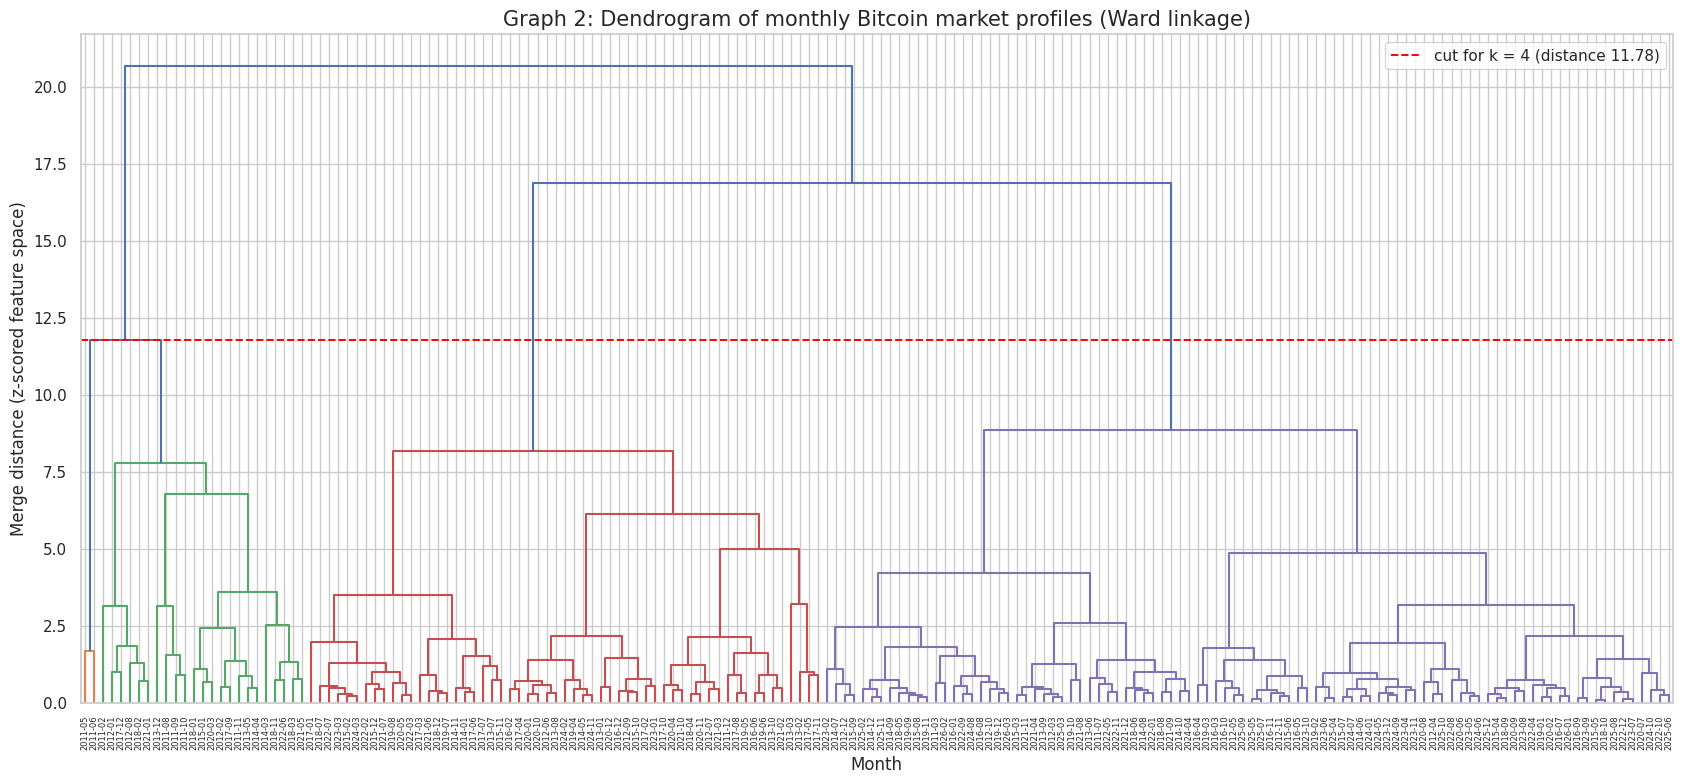

In [8]:
fig, ax = plt.subplots(figsize=(17, 8))
dd = dendrogram(Z, labels=monthly['label'].tolist(), leaf_rotation=90, leaf_font_size=6,
                color_threshold=Z[-(K-1), 2], ax=ax)
ax.axhline(Z[-(K-1), 2], color='red', linestyle='--', linewidth=1.4,
           label=f'cut for k = {K} (distance {Z[-(K-1), 2]:.2f})')
ax.set_title('Graph 2: Dendrogram of monthly Bitcoin market profiles (Ward linkage)', fontsize=15)
ax.set_ylabel('Merge distance (z-scored feature space)')
ax.set_xlabel('Month')
ax.legend()
plt.tight_layout(); plt.savefig(f"{OUT}/exp7_g2_dendrogram_months.png", dpi=150); plt.show()

In [9]:
profile = monthly.groupby('cluster')[FEATURES].mean().round(3)
profile['months'] = monthly['cluster'].value_counts().sort_index()
profile['share %'] = (profile['months'] / len(monthly) * 100).round(1)
print("CLUSTER PROFILE (means in original units)")
print(profile.to_string())

print("\nExample months in each cluster (earliest, median, latest):")
for k in sorted(monthly['cluster'].unique()):
    sub = monthly[monthly['cluster'] == k]['label'].tolist()
    print(f"  cluster {k} ({len(sub):3d} months): {sub[0]}, {sub[len(sub)//2]}, {sub[-1]}")

print("\nCluster membership by calendar year:")
tab = pd.crosstab(monthly['month'].dt.year, monthly['cluster'])
print(tab.to_string())

CLUSTER PROFILE (means in original units)
         mean_return  volatility  mean_range  pct_up_days  months  share %
cluster                                                                   
1              3.455      14.186      18.375       50.753       2      1.1
2             -0.273       7.267      10.565       45.677      23     13.1
3              0.895       3.723       5.810       61.481      57     32.4
4             -0.074       2.468       3.778       48.034      94     53.4

Example months in each cluster (earliest, median, latest):
  cluster 1 (  2 months): 2011-05, 2011-06, 2011-06
  cluster 2 ( 23 months): 2011-02, 2014-04, 2022-06
  cluster 3 ( 57 months): 2011-12, 2017-10, 2024-11
  cluster 4 ( 94 months): 2011-03, 2020-08, 2026-03

Cluster membership by calendar year:
cluster  1  2   3   4
month                
2011     2  5   1   2
2012     0  3   3   6
2013     0  2   6   2
2014     0  2   3   6
2015     0  1   4   7
2016     0  0   3   9
2017     0  2  10   0
2018

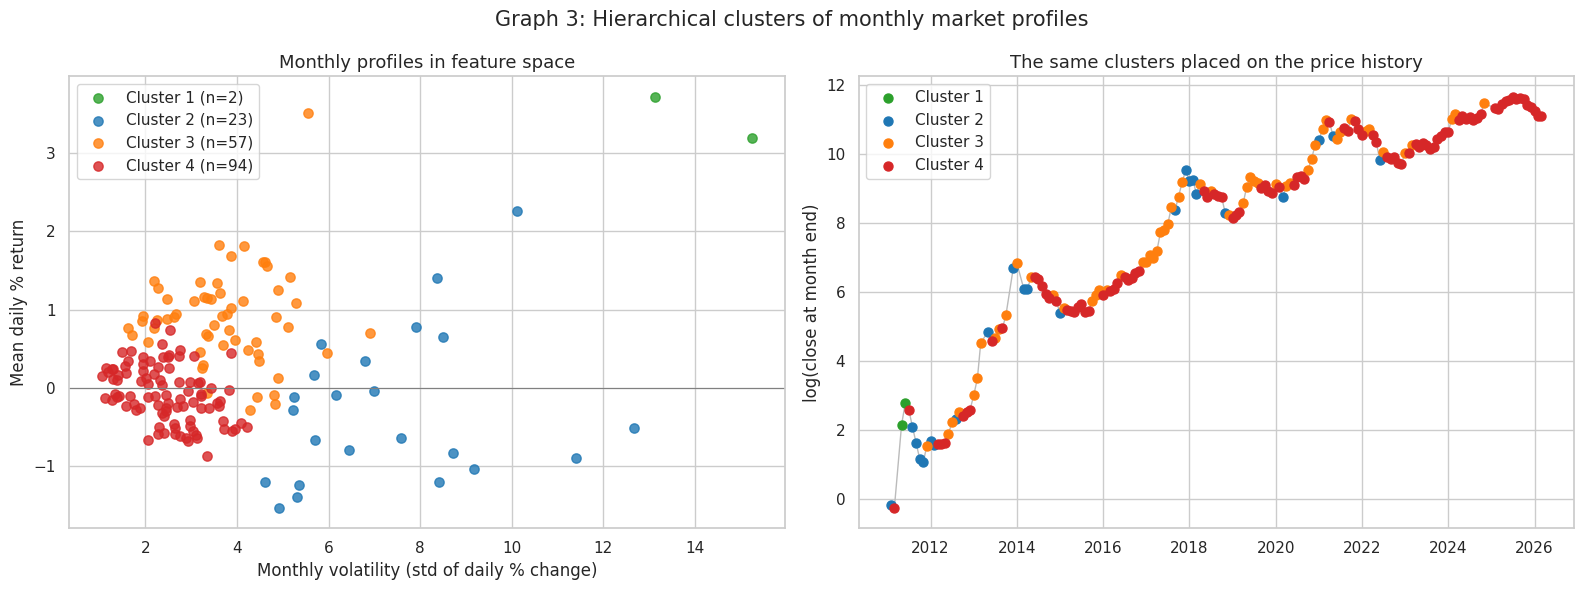

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = {1: '#2ca02c', 2: '#1f77b4', 3: '#ff7f0e', 4: '#d62728'}
for k in sorted(monthly['cluster'].unique()):
    sub = monthly[monthly['cluster'] == k]
    axes[0].scatter(sub['volatility'], sub['mean_return'], s=45, alpha=.8,
                    color=palette.get(k, 'grey'), label=f'Cluster {k} (n={len(sub)})')
axes[0].set_xlabel('Monthly volatility (std of daily % change)')
axes[0].set_ylabel('Mean daily % return')
axes[0].set_title('Monthly profiles in feature space', fontsize=13)
axes[0].axhline(0, color='grey', linewidth=.8); axes[0].legend()

months_idx = monthly['month'].dt.to_timestamp()
axes[1].plot(months_idx, np.log(monthly['close_end']), color='#bbbbbb', linewidth=1, zorder=1)
for k in sorted(monthly['cluster'].unique()):
    sub = monthly[monthly['cluster'] == k]
    axes[1].scatter(sub['month'].dt.to_timestamp(), np.log(sub['close_end']), s=42,
                    color=palette.get(k, 'grey'), label=f'Cluster {k}', zorder=2)
axes[1].set_title('The same clusters placed on the price history', fontsize=13)
axes[1].set_ylabel('log(close at month end)'); axes[1].legend()
fig.suptitle('Graph 3: Hierarchical clusters of monthly market profiles', fontsize=15)
plt.tight_layout(); plt.savefig(f"{OUT}/exp7_g3_cluster_scatter.png", dpi=150); plt.show()

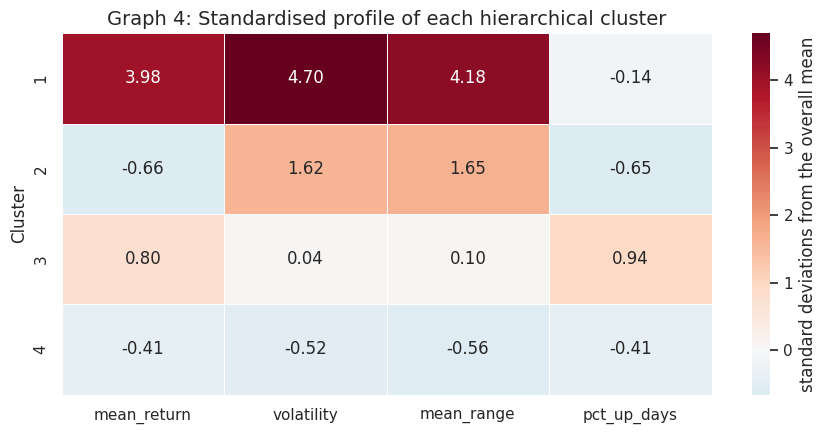

In [11]:
# Heatmap of the standardised profile of each cluster
hm = pd.DataFrame((monthly.groupby('cluster')[FEATURES].mean() - Xm_raw.mean(axis=0)) / Xm_raw.std(axis=0))
plt.figure(figsize=(9, 4.5))
sns.heatmap(hm, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=.5,
            cbar_kws={'label': 'standard deviations from the overall mean'})
plt.title('Graph 4: Standardised profile of each hierarchical cluster', fontsize=14)
plt.ylabel('Cluster'); plt.xlabel('')
plt.tight_layout(); plt.savefig(f"{OUT}/exp7_g4_profile_heatmap.png", dpi=150); plt.show()

## 5. Second Analysis — Individual Trading Days, Compared With K-Means

The same two features used by K-Means in Experiment 6 (daily % change and intraday range as % of open)
are clustered hierarchically on a random sample of 500 days, so the two methods can be compared directly
on the same data.

In [12]:
day = df.dropna(subset=['daily_pct_change', 'range_pct']).copy()
z2 = (day[['daily_pct_change', 'range_pct']] -
      day[['daily_pct_change', 'range_pct']].mean()) / day[['daily_pct_change', 'range_pct']].std()
keep = (z2.abs() <= 3).all(axis=1)                 # same shock-day rule as Experiment 6
day = day[keep].reset_index(drop=True)
print(f"Days after removing shock outliers: {len(day):,} (Experiment 6 used 5,462)")

SAMPLE = 500
samp = day.sample(SAMPLE, random_state=7).sort_values('date').reset_index(drop=True)
Xd_raw = samp[['daily_pct_change', 'range_pct']].to_numpy(float)
Xd = (Xd_raw - Xd_raw.mean(axis=0)) / Xd_raw.std(axis=0)

Zd = linkage(Xd, method='ward')                     # Ward minimises within-cluster variance
samp['hier'] = fcluster(Zd, 4, criterion='maxclust')
print("\nHierarchical (Ward, k=4) cluster sizes on the 500-day sample:")
print(samp['hier'].value_counts().sort_index().to_string())

Days after removing shock outliers: 5,462 (Experiment 6 used 5,462)

Hierarchical (Ward, k=4) cluster sizes on the 500-day sample:
hier
1     27
2    364
3     80
4     29


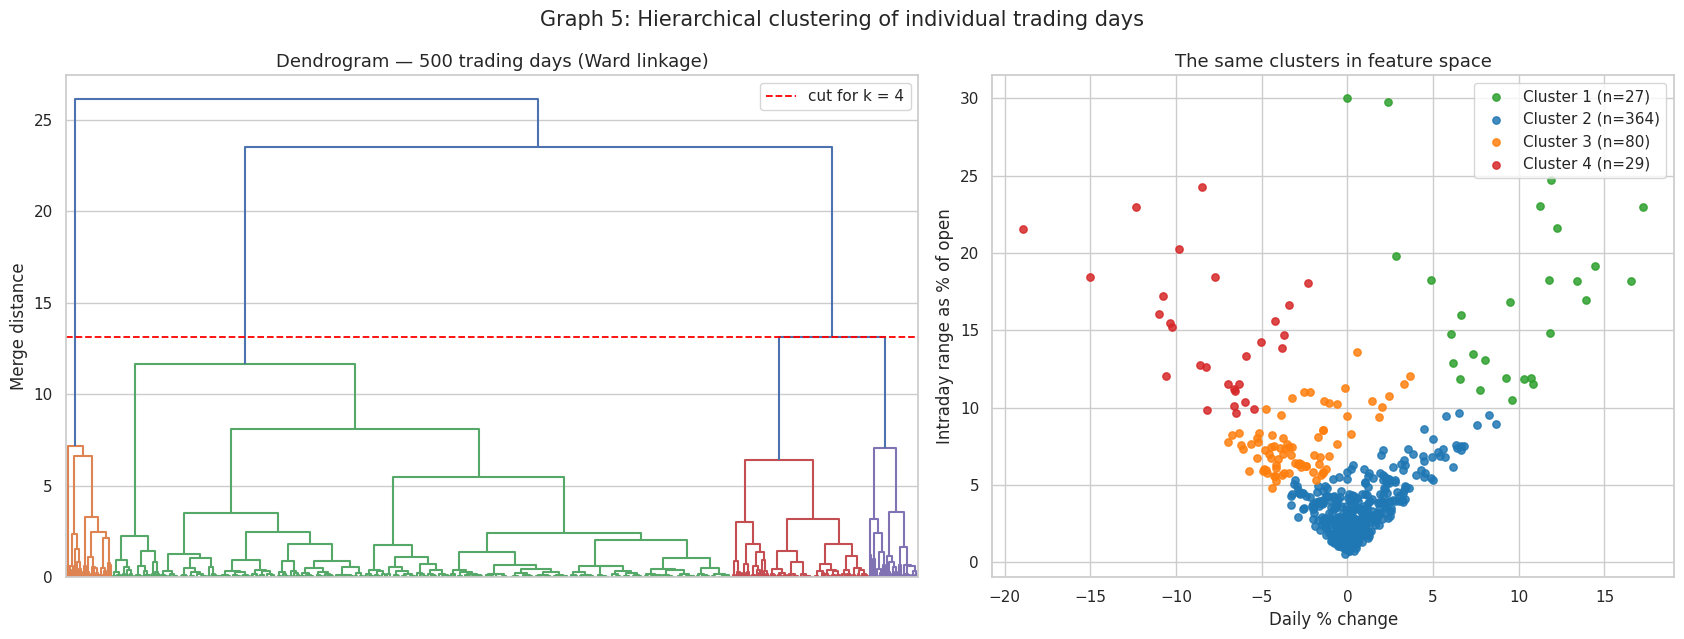

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5), gridspec_kw={'width_ratios': [1.25, 1]})
dendrogram(Zd, ax=axes[0], no_labels=True, color_threshold=Zd[-3, 2])
axes[0].axhline(Zd[-3, 2], color='red', linestyle='--', linewidth=1.3, label='cut for k = 4')
axes[0].set_title('Dendrogram — 500 trading days (Ward linkage)', fontsize=13)
axes[0].set_ylabel('Merge distance'); axes[0].legend()

cols = {1: '#2ca02c', 2: '#1f77b4', 3: '#ff7f0e', 4: '#d62728'}
for k in sorted(samp['hier'].unique()):
    sub = samp[samp['hier'] == k]
    axes[1].scatter(sub['daily_pct_change'], sub['range_pct'], s=28, alpha=.85,
                    color=cols.get(k, 'grey'), label=f'Cluster {k} (n={len(sub)})')
axes[1].set_xlabel('Daily % change'); axes[1].set_ylabel('Intraday range as % of open')
axes[1].set_title('The same clusters in feature space', fontsize=13); axes[1].legend()
fig.suptitle('Graph 5: Hierarchical clustering of individual trading days', fontsize=15)
plt.tight_layout(); plt.savefig(f"{OUT}/exp7_g5_days_dendrogram.png", dpi=150); plt.show()

In [14]:
# Compare the hierarchical partition with the K-Means regimes of Experiment 6
def kmeans_labels(X, k, seed=2026, iters=200):
    rng = np.random.default_rng(seed)
    C = X[rng.choice(len(X), k, replace=False)]
    for _ in range(iters):
        d = np.sqrt(((X[:, None, :] - C[None, :, :]) ** 2).sum(2))
        lab = d.argmin(1)
        newC = np.array([X[lab == i].mean(0) if (lab == i).any() else C[i] for i in range(k)])
        if np.allclose(newC, C): break
        C = newC
    return lab, C

km_lab, km_C = kmeans_labels(Xd, 4)
samp['kmeans'] = km_lab + 1

ct = pd.crosstab(samp['hier'], samp['kmeans'])
print("Agreement between the hierarchical and K-Means partitions (same 500 days)")
print(ct.to_string())

# Adjusted Rand index, implemented directly
def adjusted_rand(a, b):
    from math import comb
    ct = pd.crosstab(a, b).to_numpy()
    sum_c = sum(comb(int(v), 2) for v in ct.flatten())
    sum_a = sum(comb(int(v), 2) for v in ct.sum(1))
    sum_b = sum(comb(int(v), 2) for v in ct.sum(0))
    n = comb(int(ct.sum()), 2)
    exp = sum_a * sum_b / n
    return (sum_c - exp) / (0.5 * (sum_a + sum_b) - exp)

ari = adjusted_rand(samp['hier'], samp['kmeans'])
agree = ct.max(axis=1).sum() / len(samp)
print(f"\nAdjusted Rand Index : {ari:.4f}   (1 = identical partitions, 0 = random agreement)")
print(f"Best-match agreement: {agree*100:.1f}% of days fall in corresponding clusters")

Agreement between the hierarchical and K-Means partitions (same 500 days)
kmeans   1    2   3   4
hier                   
1        0    0  26   1
2       18  333  13   0
3       77    0   3   0
4        4    0   0  25

Adjusted Rand Index : 0.7895   (1 = identical partitions, 0 = random agreement)
Best-match agreement: 92.2% of days fall in corresponding clusters


## 6. Cluster Interpretation

### 6.1 The four monthly market types (Ward, k = 4, 176 months)

| Cluster | Months | Share | Mean daily return | Volatility | Mean range | % up days | Reading |
|---|---|---|---|---|---|---|---|
| 4 | 94 | 53.4% | −0.07% | 2.47 | 3.78% | 48.0% | **Quiet drift** — the market's default state |
| 3 | 57 | 32.4% | +0.90% | 3.72 | 5.81% | 61.5% | **Steady bull month** — grinding upward on modest daily moves |
| 2 | 23 | 13.1% | −0.27% | 7.27 | 10.57% | 45.7% | **Turbulent / bear month** — wide swings, more down days than up |
| 1 | 2 | 1.1% | +3.46% | 14.19 | 18.38% | 50.8% | **Mania** — May and June 2011, the first parabolic bubble |

### 6.2 What the hierarchy shows

1. **The tree separates volatility before it separates direction.** The first split of the dendrogram
   divides calm months from turbulent ones; only lower down does the direction of the move matter. That is
   the same structure K-Means found in Experiment 6, arrived at by a completely different route.
2. **Quiet months have taken over.** Cluster 4 (quiet drift) accounts for 10 of 12 months in 2023, 11 of
   11 in 2025 and all of 2026 so far, against 2 of 8 in 2011. Turbulent months (cluster 2) are
   concentrated in 2011-2018 and have not appeared at all since 2022.
3. **Bull months are a distinct type, not just "up" months.** Cluster 3 has 61.5% up days and a modest
   3.72 volatility: sustained advances are made of many small gains, not a few violent ones. All ten
   months of the 2017 bull run fall in this cluster.
4. **The 2011 bubble is genuinely its own kind of month.** May and June 2011 sit alone in cluster 1 with
   volatility 14.19 — nearly six times the calm-month level.

### 6.3 Cross-check against K-Means (Experiment 6)

On the same 500 sampled trading days and the same two features, the hierarchical partition (Ward, k = 4)
and the K-Means partition agree on **92.2% of days**, with an **Adjusted Rand Index of 0.7895**. Two
algorithms with completely different mechanics — one greedy and iterative, one bottom-up and
deterministic — recover essentially the same structure, which is the strongest available evidence that
the regimes are a property of the data and not of the algorithm.

### 6.4 Hierarchical versus partitional clustering, as observed here

| | K-Means (Experiment 6) | Agglomerative (this experiment) |
|---|---|---|
| k required in advance | yes | no — the tree is cut afterwards |
| Result stability | depends on the initial centroids; needs restarts | deterministic for a given linkage |
| Complexity | O(n·k·d·i), scales to the full 5,462 days | O(n³) time, O(n²) memory — a 500-day sample here |
| Output | a flat partition | a full hierarchy showing how clusters nest |
| Outlier behaviour | an outlier drags its centroid | an outlier forms its own branch |

## 7. Conclusion

Agglomerative hierarchical clustering was implemented from first principles — full proximity matrix,
nearest-pair search and the Lance-Williams update for single, complete, average and Ward linkage — and
verified against `scipy.cluster.hierarchy.linkage`, matching its merge sequence exactly and its merge
heights to 1.8e-15.

Four linkage rules were compared on 176 monthly market profiles. Average linkage preserved the pairwise
distances best (cophenetic correlation 0.848) but placed 95.5% of the months in one cluster; Ward
linkage, at a lower cophenetic correlation of 0.606, produced the only balanced and interpretable
partition (94 / 57 / 23 / 2) and was used for the analysis. The dendrogram separates volatility first and
direction second, and shows quiet months displacing turbulent ones over time — no turbulent month since
2022, against five in 2011.

On individual trading days the hierarchical partition agrees with the K-Means regimes of Experiment 6 on
92.2% of days (Adjusted Rand Index 0.79), an independent confirmation that the market-regime structure is
real rather than an artefact of either algorithm.